# Eval Overview - Mechanism of Action Matching

The Mechanism of Action (MoA) matching evaluation is a set of benchmarks that evaluate whether perturbations targeting genes in the same biological pathway produce similar predicted latent representation and expression changes. The test is to understand if the model has built out biological understanding, specifically that if a pathway is upregulated, all the genes should express more, or, if a pathway is knocked out, the genes in it should be disrupted together. This eval uses two representations of the perturbation effect: the latent delta from the model's internal representation, and the expression delta produced by the [linear expression decoder](https://github.com/GPTomics/biojepa/blob/main/layer_explainers/explainer_eval_decoders.ipynb). For our production data, we also use known pathways, in particular the [KEGG Pathways 2026](https://maayanlab.cloud/Harmonizome/dataset/KEGG+Pathways+2026) definitions that link 8116 genes to 356 pathways.

We use cosine similarities to compare pathways. Since a perturbation can be in many pathways at once, a pair of perturbations is "within-pathway" if they share any pathway. As you walk through the notebook you'll see how we evaluate the model's ability to capture pathway-level relationships, a signal that goes beyond predicting individual perturbation effects and highlights whether the model has learned some of the physics of a cell.

In [1]:
import numpy as np
from scipy.stats import mannwhitneyu
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [2]:
SEED = 1337
np.random.seed(SEED)

## Data Prep
We'll start by preparing our data. For this evaluation, we need the average perturbation effect in both expression space (*expression delta*) and latent space (*latent delta*) by perturbation, along with a set of pathway annotations that tell us which genes belong to which biological pathways. 

The expression delta comes from the linear decoder's output. The latent delta comes from the model's internal representation before decoding, specifically the difference between the predicted and control latent states mean-pooled across genes. A "perturbation" is a unique combination of a sequence, target, modality, and mode applied to a cell type. A perturbation can span datasets. Since we have a few different notebooks showing how sample-level deltas are computed, we'll go ahead and just stage the per-perturbation deltas directly.

After we stage the deltas, we'll then create our pathway annotations and our gene-to-pathway labels. We'll stage a few different relationships to emphasize how the calculation highlights strengths and weaknesses.

In [ ]:
num_genes = 8
embed_dim = 4
unique_perts = 10

### Perturbations

We'll first start with our perturbations. With this dataset we'll create 10 perturbations covering all 10 genes across the pathways we'll stage. To define a unique perturbation, it's not just about what we perturb, but the context of it. Because of this, we represent a unique perturbation as $\text{(seq id, targ id, modality id, mode id, cell type)}$. IDs are used since our model keeps the perturbation information in separate caches from our sample expression counts to avoid heavy duplication of information.

You'll see that we've staged a mix of perturbations: the first 7 are DNA-based (a mix of CRISPRi and CRISPRa), then we have a couple target-only perturbations where no sequence embedding was available, and finally a chemical inhibitor.

In [4]:
pert_keys = [
    (0, 0, 0, 0, 0),   # DNA CRISPRi, cell type 0
    (1, 1, 0, 0, 0),   # DNA CRISPRi, cell type 0
    (2, 2, 0, 1, 0),   # DNA CRISPRa, cell type 0
    (3, 3, 0, 1, 0),   # DNA CRISPRa, cell type 0
    (4, 4, 0, 0, 0),   # DNA CRISPRi, cell type 0
    (5, 5, 0, 1, 0),   # DNA CRISPRa, cell type 0
    (6, 6, 0, 0, 0),   # DNA CRISPRi, cell type 0
    (-1, 7, 0, 0, 0),  # target-only, no sequence embedding
    (-1, 8, 0, 0, 0),  # target-only, no sequence embedding
    (0, 9, 2, 4, 0),   # chemical inhibitor
]
pert_keys

[(0, 0, 0, 0, 0),
 (1, 1, 0, 0, 0),
 (2, 2, 0, 1, 0),
 (3, 3, 0, 1, 0),
 (4, 4, 0, 0, 0),
 (5, 5, 0, 1, 0),
 (6, 6, 0, 0, 0),
 (-1, 7, 0, 0, 0),
 (-1, 8, 0, 0, 0),
 (0, 9, 2, 4, 0)]

**Perturbation to Gene Mapping**

Next, we need to know what gene each perturbation perturbs. Currently, if it's a multi-perturbation we skip it. During our data prep, we create `seq_to_gene` that tells us for DNA perturbations what gene the guide RNA knocks down, and we use `target_to_gene` to identify for target-only and chemical perturbations the gene it perturbs via its protein target. This gene label is how we map a perturbation to the gene to then identify the pathway labels.

We'll create a simple incremental labeling where each perturbation perturbs the next gene. We'll also make the sequence and target to gene mappings the same here, when in reality, they'd be different dictionaries.

In [5]:
seq_to_gene = {i: f'GENE_{i+1}' for i in range(10)}
target_to_gene = seq_to_gene
all_genes = [seq_to_gene[g] for g in seq_to_gene.keys()]
seq_to_gene, target_to_gene, all_genes

({0: 'GENE_1',
  1: 'GENE_2',
  2: 'GENE_3',
  3: 'GENE_4',
  4: 'GENE_5',
  5: 'GENE_6',
  6: 'GENE_7',
  7: 'GENE_8',
  8: 'GENE_9',
  9: 'GENE_10'},
 {0: 'GENE_1',
  1: 'GENE_2',
  2: 'GENE_3',
  3: 'GENE_4',
  4: 'GENE_5',
  5: 'GENE_6',
  6: 'GENE_7',
  7: 'GENE_8',
  8: 'GENE_9',
  9: 'GENE_10'},
 ['GENE_1',
  'GENE_2',
  'GENE_3',
  'GENE_4',
  'GENE_5',
  'GENE_6',
  'GENE_7',
  'GENE_8',
  'GENE_9',
  'GENE_10'])

### Per-perturbation Expression Deltas
Now we'll stage our per-perturbation expression deltas. To calculate these, we first compute sample-level predicted deltas as $\hat{\delta}_g = \hat{x}^{\text{case}}_g - \hat{x}^{\text{ctrl}}_g$, the predicted perturbed expression minus the predicted control expression. We use the predicted control expression to isolate BioJEPA-AC's learned perturbation effect from any baseline reconstruction error.

After we have the sample-level delta, we then take the mean of the delta per perturbation. Since we have a few different notebooks showing this already, we'll go ahead and just stage the per-perturbation expression delta.

In [6]:
mean_pred_deltas = np.array([
    [ 1.2,  0.9, -0.8, -1.1,  0.1,  0.0,  0.05, -0.1 ],
    [ 1.1,  1.0, -0.9, -1.0,  0.15, 0.05, 0.0,  -0.05],
    [ 0.8,  0.6, -0.5,  0.7,  0.9,  0.1,  0.0,  -0.1 ],
    [ 0.7,  0.5, -0.4,  0.8,  0.85, 0.15, 0.05, -0.05],
    [ 0.1,  0.0, -0.1,  1.0,  1.2,  0.2,  0.0,  -0.1 ],
    [ 0.05, 0.1, -0.05, 0.9,  1.1,  0.3,  0.05, -0.05],
    [ 0.0,  0.05, 0.0,  1.1,  1.0,  0.25, 0.1,  -0.1 ],
    [ 0.0, -0.1,  0.05, 0.0,  0.1,  1.3, -0.9,   1.1 ],
    [-0.05,-0.05, 0.1,  0.05, 0.0,  1.2, -1.0,   1.0 ],
    [ 0.1, -0.1,  0.0,  0.0,  0.05, 1.1, -0.85,  1.15],
])
mean_pred_deltas.shape, mean_pred_deltas

((10, 8),
 array([[ 1.2 ,  0.9 , -0.8 , -1.1 ,  0.1 ,  0.  ,  0.05, -0.1 ],
        [ 1.1 ,  1.  , -0.9 , -1.  ,  0.15,  0.05,  0.  , -0.05],
        [ 0.8 ,  0.6 , -0.5 ,  0.7 ,  0.9 ,  0.1 ,  0.  , -0.1 ],
        [ 0.7 ,  0.5 , -0.4 ,  0.8 ,  0.85,  0.15,  0.05, -0.05],
        [ 0.1 ,  0.  , -0.1 ,  1.  ,  1.2 ,  0.2 ,  0.  , -0.1 ],
        [ 0.05,  0.1 , -0.05,  0.9 ,  1.1 ,  0.3 ,  0.05, -0.05],
        [ 0.  ,  0.05,  0.  ,  1.1 ,  1.  ,  0.25,  0.1 , -0.1 ],
        [ 0.  , -0.1 ,  0.05,  0.  ,  0.1 ,  1.3 , -0.9 ,  1.1 ],
        [-0.05, -0.05,  0.1 ,  0.05,  0.  ,  1.2 , -1.  ,  1.  ],
        [ 0.1 , -0.1 ,  0.  ,  0.  ,  0.05,  1.1 , -0.85,  1.15]]))

### Per-perturbation Latent Deltas

In addition to expression deltas, we also compare perturbation effects in the model's raw latent space, before the decoder projects to expression. The ACPredictor outputs a predicted latent representation `z_pred_mu` of shape `[B, num_genes, embed_dim]`. To isolate the perturbation effect, we subtract the control baseline `z_context` and then mean-pool across the gene axis to get a single vector per sample:

```
z_latent_delta = (z_pred_mu - z_context).mean(dim=1)   # [B, embed_dim]
```

This is similar to the expression delta logic where we compute `decoder(z_pred_mu) - decoder(z_context)`, but it operates upstream of the decoder. By removing the decoder and getting the difference in the latent space, we get a better understanding of our raw model's performance compared to that of the linear decoder. The mean-pool collapses the per-gene latent changes into one `[embed_dim]` summary vector that captures the overall direction of the perturbation effect in latent space. We then average across replicates of the same perturbation, just like we do for expression deltas.

In [ ]:
mean_latent_deltas = np.array([
    [0.9,0.8,-0.1,-0.2],
    [0.85,0.75,-0.05,-0.15],
    [0.5,0.4,0.5,0.4],
    [0.45,0.35,0.55,0.45],
    [-0.1,-0.2,0.9,0.8],
    [-0.05,-0.15,0.85,0.75],
    [0.3,0.2,0.7,0.6],
    [-0.1,0.0,-0.1,0.9],
    [-0.15,0.05,-0.05,0.85],
    [-0.05,-0.05,-0.15,0.95]
])
mean_latent_deltas.shape, mean_latent_deltas

### Pathway Annotations
Now we'll set up our pathway annotations. Instead of pulling the KEGG dataset we use in our production eval, we'll stage three pathways. We'll set up the first two pathways to have a deliberate overlap and our third pathway will have a unique set of genes. 

We'll also build the inverse of our pathways that tells us, for each gene, which pathways it is in. Having this quick lookup will help when comparing gene distances. You'll see that GENE_3, GENE_4, and GENE_7 each appear in two pathways, while the other genes appear in exactly one.

In [8]:
staged_pathway = {
    'pathway_a': ['GENE_1', 'GENE_2', 'GENE_3', 'GENE_4', 'GENE_7'],
    'pathway_b': ['GENE_3', 'GENE_4', 'GENE_5', 'GENE_6', 'GENE_7'],
    'pathway_c': ['GENE_8', 'GENE_9', 'GENE_10'],
}
staged_pathway

{'pathway_a': ['GENE_1', 'GENE_2', 'GENE_3', 'GENE_4', 'GENE_7'],
 'pathway_b': ['GENE_3', 'GENE_4', 'GENE_5', 'GENE_6', 'GENE_7'],
 'pathway_c': ['GENE_8', 'GENE_9', 'GENE_10']}

In [9]:
gene_to_pathways = {g:[] for g in all_genes}
for pathway, genes in staged_pathway.items():
    for gene in genes:
        gene_to_pathways[gene].append(pathway)
        
gene_to_pathways

{'GENE_1': ['pathway_a'],
 'GENE_2': ['pathway_a'],
 'GENE_3': ['pathway_a', 'pathway_b'],
 'GENE_4': ['pathway_a', 'pathway_b'],
 'GENE_5': ['pathway_b'],
 'GENE_6': ['pathway_b'],
 'GENE_7': ['pathway_a', 'pathway_b'],
 'GENE_8': ['pathway_c'],
 'GENE_9': ['pathway_c'],
 'GENE_10': ['pathway_c']}

### Perturbation to Pathway
Our final piece is mapping each perturbation to its pathways. Now that we know the genes in a pathway and have our `gene_to_pathways` dictionary, we can identify which pathways a perturbation is impacting. Recall that we use the sequence idx for matching DNA perturbations to the perturbed gene and for other perturbations we use the target idx. Here you'll see how we create that mapping and a list that includes the pathways by perturbation order. This list will be the final portion of our data prep.

*In our production data you'll see that we do filtering on pathways to ensure we only include pathways that aren't too small or too big to prevent comparing outliers.*

In [10]:
pert_pathways = []
for key in pert_keys:
    seq_idx, target_idx, modality = key[0], key[1], key[2]
    if modality == 0 and seq_idx >= 0 and seq_idx in seq_to_gene:
        gene = seq_to_gene[seq_idx]
        source = 'seq'
    else:
        gene = target_to_gene[target_idx]
        source = 'target'
    pert_pathways.append(gene_to_pathways[gene])
    print(f'Pert {len(pert_pathways)-1}: {gene} -> {pert_pathways[-1]}  (via {source})')

pert_pathways

Pert 0: GENE_1 -> ['pathway_a']  (via seq)
Pert 1: GENE_2 -> ['pathway_a']  (via seq)
Pert 2: GENE_3 -> ['pathway_a', 'pathway_b']  (via seq)
Pert 3: GENE_4 -> ['pathway_a', 'pathway_b']  (via seq)
Pert 4: GENE_5 -> ['pathway_b']  (via seq)
Pert 5: GENE_6 -> ['pathway_b']  (via seq)
Pert 6: GENE_7 -> ['pathway_a', 'pathway_b']  (via seq)
Pert 7: GENE_8 -> ['pathway_c']  (via target)
Pert 8: GENE_9 -> ['pathway_c']  (via target)
Pert 9: GENE_10 -> ['pathway_c']  (via target)


[['pathway_a'],
 ['pathway_a'],
 ['pathway_a', 'pathway_b'],
 ['pathway_a', 'pathway_b'],
 ['pathway_b'],
 ['pathway_b'],
 ['pathway_a', 'pathway_b'],
 ['pathway_c'],
 ['pathway_c'],
 ['pathway_c']]

## Expression Delta Similarity Evaluation

We'll first start by evaluating similarities based on expression delta.

### Cosine Similarity Calculation

To determine if our model is predicting perturbations with impacts on the same pathways as closer than between pathways, we need to identify the distance between our expression delta profiles. We do this by computing pairwise cosine similarity on all of our perturbation deltas. Cosine similarity measures the angle between two vectors, irrespective of magnitude. We calculate it as:
$$
\text{cos\_sim}(d_i, d_j) = \frac{\sum_{g=1}^{G} d_{i,g} \cdot d_{j,g}}{\sqrt{\sum_{g=1}^{G} d_{i,g}^{2}} \cdot \sqrt{\sum_{g=1}^{G} d_{j,g}^{2}}}
$$
where $d_i$ is the mean predicted expression delta for perturbation $i$ across all $G$ genes. If two perturbations have similar changes in expression, we expect that they'll have high cosine similarity, even if one has a stronger overall effect. You'll see because of how we calculate this, the diagonal will be all 1 since it's a similarity of the perturbation to itself. Similar to other correlations, either a highly negative $-1$ or highly positive value $+1$ is valuable as they're anti-correlated or correlated. Values around zero are the most noisy.

In [11]:
sim_matrix = cosine_similarity(mean_pred_deltas)
sim_matrix.shape, sim_matrix

((10, 10),
 array([[ 1.        ,  0.99392193,  0.37788375,  0.2676935 , -0.2393721 ,
         -0.23032046, -0.34136392, -0.07010556, -0.10330068, -0.03332609],
        [ 0.99392193,  1.        ,  0.42632687,  0.31778969, -0.18981262,
         -0.17624919, -0.28955425, -0.03087365, -0.06281934,  0.00411838],
        [ 0.37788375,  0.42632687,  1.        ,  0.9913586 ,  0.76383281,
          0.76078797,  0.71440021,  0.00807186, -0.02180548,  0.02067347],
        [ 0.2676935 ,  0.31778969,  0.9913586 ,  1.        ,  0.81961133,
          0.81954165,  0.78626001,  0.03762487,  0.00710773,  0.04653943],
        [-0.2393721 , -0.18981262,  0.76383281,  0.81961133,  1.        ,
          0.9925583 ,  0.98329492,  0.08657831,  0.0594046 ,  0.06101405],
        [-0.23032046, -0.17624919,  0.76078797,  0.81954165,  0.9925583 ,
          1.        ,  0.98599644,  0.13743014,  0.10778417,  0.1059734 ],
        [-0.34136392, -0.28955425,  0.71440021,  0.78626001,  0.98329492,
          0.98599644,

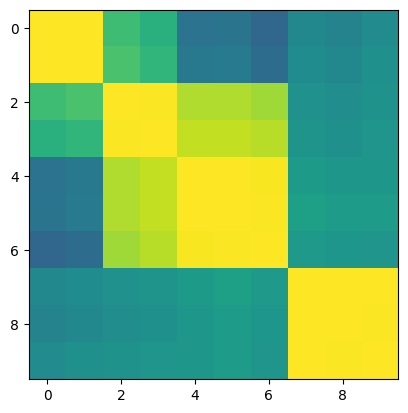

In [12]:
plt.imshow(sim_matrix, vmin=-1, vmax=1)

### Labeling Within/Between

Now that we have our similarity, we need to go through and, using our mapping of perturbations to shared pathways, label each pairwise distance as being 
* **within-pathway** meaning the two perturbations' impacted genes share one or more pathways
* **between-pathway** meaning the two perturbations' impacted genes do NOT have a common pathway

We'll go through and create a list of within and between similarities. You'll notice that the three overlapping genes are treated the same as any other pathway share as this is just a binary: shares or does not share.

In [13]:
within_sims, between_sims = [], []

for i in range(unique_perts):
    for j in range(i + 1, unique_perts):
        shared = set(pert_pathways[i]) & set(pert_pathways[j])
        sim = sim_matrix[i, j]
        if shared:
            within_sims.append(sim)
            print(f'  WITHIN  pert {i} & {j}: shared={shared}, sim={sim:.3f}')
        else:
            between_sims.append(sim)

  WITHIN  pert 0 & 1: shared={'pathway_a'}, sim=0.994
  WITHIN  pert 0 & 2: shared={'pathway_a'}, sim=0.378
  WITHIN  pert 0 & 3: shared={'pathway_a'}, sim=0.268
  WITHIN  pert 0 & 6: shared={'pathway_a'}, sim=-0.341
  WITHIN  pert 1 & 2: shared={'pathway_a'}, sim=0.426
  WITHIN  pert 1 & 3: shared={'pathway_a'}, sim=0.318
  WITHIN  pert 1 & 6: shared={'pathway_a'}, sim=-0.290
  WITHIN  pert 2 & 3: shared={'pathway_b', 'pathway_a'}, sim=0.991
  WITHIN  pert 2 & 4: shared={'pathway_b'}, sim=0.764
  WITHIN  pert 2 & 5: shared={'pathway_b'}, sim=0.761
  WITHIN  pert 2 & 6: shared={'pathway_b', 'pathway_a'}, sim=0.714
  WITHIN  pert 3 & 4: shared={'pathway_b'}, sim=0.820
  WITHIN  pert 3 & 5: shared={'pathway_b'}, sim=0.820
  WITHIN  pert 3 & 6: shared={'pathway_b', 'pathway_a'}, sim=0.786
  WITHIN  pert 4 & 5: shared={'pathway_b'}, sim=0.993
  WITHIN  pert 4 & 6: shared={'pathway_b'}, sim=0.983
  WITHIN  pert 5 & 6: shared={'pathway_b'}, sim=0.986
  WITHIN  pert 7 & 8: shared={'pathway_c'

In [14]:
within_sims = np.array(within_sims)
between_sims = np.array(between_sims)
f'Within pairs: {len(within_sims)}, Between pairs: {len(between_sims)}'

'Within pairs: 20, Between pairs: 25'

### Mean Within and Between Cosine Similarity

With our similarities calculated and tagged into their classes, we're ready to start comparing the values. Our first set of evaluation will be just calculating the means of the two groups. The goal is that the mean within is more strongly correlated. You'll see that with our sample data, we've managed to make that the case.

*Note that if this metric is not strongly indicative, it does not mean the model failed to learn the biology, just that it may not have learned the particular pathways we're evaluating them on. This metric will heavily depend on which gene network dataset you pick.*

In [15]:
mean_within = float(np.mean(within_sims))
mean_within

0.6671947806374602

In [16]:
mean_between = float(np.mean(between_sims))
mean_between

-0.012104221433031056

### Within/Between Gap
Next we take the difference between our two means. The goal here is that it's either very positive or negative, showing a big difference. Once again, the goal is that the model has learned a correlation, whether it's positive, negative, or an inverse we want to see that we have a difference between the two groups showing the model is finding a differentiation on networks. We calculate the gap as
$$
\text{gap} = \bar{s}_{\text{within}} - \bar{s}_{\text{between}}
$$

With our sample data, we get a fairly large gap, especially when comparing against the *between* that is close to 0.

In [17]:
gap = mean_within - mean_between
gap

0.6792990020704912

### Within/Between Ratio

Next we want to know "how much better". Even if both our values are negative, a stronger negative for one of the metrics tells us a lot. We calculate the ratio as:
$$
\text{ratio} = \frac{\bar{s}_{\text{within}}}{\bar{s}_{\text{between}}}
$$

A ratio above 1.0 tells us that the within group is showing more similarity than the between group. The ratio is only meaningful when both means have the same sign (both positive or both negative). When the signs differ, the ratio produces a negative number that isn't interpretable on this scale, so we return infinity and rely on the gap instead. Because of our data staging, you'll see that the signs differ here, so the ratio returns inf.

In [18]:
ratio = mean_within / mean_between if mean_within * mean_between > 0 else float('inf')
ratio

inf

### Mann-Whitney U Test

Now that we've done simple math on the similarities, we need to determine if, statistically, the differences in distribution are significant. For this we use the Mann-Whitney U test that checks whether values from one distribution tend to be larger than values from the other, without assuming normality. We calculate it as:
$$\begin{aligned}
U &= \sum_{i=1}^{n_w} \sum_{j=1}^{n_b} \mathbf{1}[s_{\text{within},i} > s_{\text{between},j}] \\
z &= \frac{U - \frac{n_w \cdot n_b}{2}}{\sqrt{\frac{n_w \cdot n_b \cdot (n_w + n_b + 1)}{12}}}
\end{aligned}$$

where $n_w$ and $n_b$ are the number of within-pathway and between-pathway pairs. $U$ counts how many times a within-pathway similarity exceeds a between-pathway similarity. The $z$-score normalizes against the expected value under the null hypothesis (no difference between groups), and the p-value comes from the upper tail of the normal distribution as:
$$
p = P(Z \geq z) = 1 - \Phi(z)
$$
where $\Phi$ is the standard normal CDF. Put simply, we assume that there is no difference and we're testing with our data to see if we can reject that there's not a difference (based on p-value). The smaller the value, the more we are confident there is a difference between our two groups.

In [19]:
_, p_val = mannwhitneyu(within_sims, between_sims, alternative='greater')
p_val = float(p_val)
p_val

2.59569238313773e-06

## Latent Delta Similarity Evaluation

Now we'll evaluate the similarity based on our latent delta. The calculations are the same as expression so we'll mainly focus on the differences in results.

### Cosine Similarity Calculation
We'll start with similarity. One big difference you'll notice here is that, if you look at the heatmap, there's a lot less definition in our three pathways, and more noise, in particular between our last two.

In [20]:
lat_sim_matrix = cosine_similarity(mean_latent_deltas)
lat_sim_matrix.shape, lat_sim_matrix

((10, 10),
 array([[ 1.        ,  0.99872693,  0.57706857,  0.48395957, -0.33333333,
         -0.28535055,  0.19794866, -0.23301757, -0.24513035, -0.22013355],
        [ 0.99872693,  1.        ,  0.61750062,  0.52745814, -0.28535055,
         -0.23664122,  0.24712083, -0.20618818, -0.21690631, -0.19478761],
        [ 0.57706857,  0.61750062,  1.        ,  0.99395765,  0.57706857,
          0.61750062,  0.91473203,  0.3151573 ,  0.33153989,  0.29773161],
        [ 0.48395957,  0.52745814,  0.99395765,  1.        ,  0.66320386,
          0.7000808 ,  0.95355636,  0.36746988,  0.38657179,  0.34715172],
        [-0.33333333, -0.28535055,  0.57706857,  0.66320386,  1.        ,
          0.99872693,  0.85777754,  0.57358172,  0.60339779,  0.54186721],
        [-0.28535055, -0.23664122,  0.61750062,  0.7000808 ,  0.99872693,
          1.        ,  0.88257438,  0.5706138 ,  0.60027559,  0.5390634 ],
        [ 0.19794866,  0.24712083,  0.91473203,  0.95355636,  0.85777754,
          0.88257438,

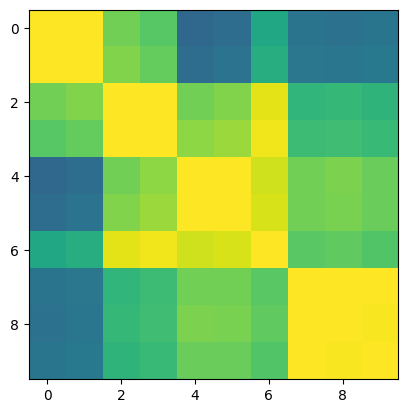

In [21]:
plt.imshow(lat_sim_matrix, vmin=-1, vmax=1)

### Labeling Within/Between
The within/between labels are the same as expression since we're comparing the same perturbations against the same pathway annotations. Only the similarity matrix changed.

In [22]:
lat_within_sims, lat_between_sims = [], []

for i in range(unique_perts):
    for j in range(i + 1, unique_perts):
        shared = set(pert_pathways[i]) & set(pert_pathways[j])
        sim = lat_sim_matrix[i, j]
        if shared:
            lat_within_sims.append(sim)
            print(f'  WITHIN  pert {i} & {j}: shared={shared}, sim={sim:.3f}')
        else:
            lat_between_sims.append(sim)

  WITHIN  pert 0 & 1: shared={'pathway_a'}, sim=0.999
  WITHIN  pert 0 & 2: shared={'pathway_a'}, sim=0.577
  WITHIN  pert 0 & 3: shared={'pathway_a'}, sim=0.484
  WITHIN  pert 0 & 6: shared={'pathway_a'}, sim=0.198
  WITHIN  pert 1 & 2: shared={'pathway_a'}, sim=0.618
  WITHIN  pert 1 & 3: shared={'pathway_a'}, sim=0.527
  WITHIN  pert 1 & 6: shared={'pathway_a'}, sim=0.247
  WITHIN  pert 2 & 3: shared={'pathway_b', 'pathway_a'}, sim=0.994
  WITHIN  pert 2 & 4: shared={'pathway_b'}, sim=0.577
  WITHIN  pert 2 & 5: shared={'pathway_b'}, sim=0.618
  WITHIN  pert 2 & 6: shared={'pathway_b', 'pathway_a'}, sim=0.915
  WITHIN  pert 3 & 4: shared={'pathway_b'}, sim=0.663
  WITHIN  pert 3 & 5: shared={'pathway_b'}, sim=0.700
  WITHIN  pert 3 & 6: shared={'pathway_b', 'pathway_a'}, sim=0.954
  WITHIN  pert 4 & 5: shared={'pathway_b'}, sim=0.999
  WITHIN  pert 4 & 6: shared={'pathway_b'}, sim=0.858
  WITHIN  pert 5 & 6: shared={'pathway_b'}, sim=0.883
  WITHIN  pert 7 & 8: shared={'pathway_c'},

In [23]:
lat_within_sims = np.array(lat_within_sims)
lat_between_sims = np.array(lat_between_sims)
f'Latent Within pairs: {len(lat_within_sims)}, Between pairs: {len(lat_between_sims)}'

'Latent Within pairs: 20, Between pairs: 25'

### Mean Within and Between Cosine Similarity
Here you can start seeing why we saw more noise. Both of our means are now positive, though our mean *within* is even stronger now, showing tighter clustering within pathways.

In [24]:
lat_mean_within = float(np.mean(lat_within_sims))
lat_mean_within

0.7390839246951852

In [25]:
lat_mean_between = float(np.mean(lat_between_sims))
lat_mean_between

0.17918263463261444

### Within/Between Gap
This is where the noise becomes more pronounced. We can see that the gap shrank despite having stronger within similarity, mainly because of the rise of the between similarity.

In [26]:
lat_gap = lat_mean_within - lat_mean_between
lat_gap

0.5599012900625708

### Within/Between Ratio
This time we can get a ratio since both of our similarities are positive. Our ratio is quite high, telling us there's clear separation between the two groupings.

In [27]:
lat_ratio = lat_mean_within / lat_mean_between if lat_mean_within * lat_mean_between > 0 else float('inf')
lat_ratio

4.124751967234769

### Mann-Whitney U Test
Just because we have a high ratio, we can't just outright claim it's significant. We need to actually calculate the significance, and, as you'll see, it's quite low, meaning that we can claim there's a significant difference between the groups.

In [28]:
_, lat_p_val = mannwhitneyu(lat_within_sims, lat_between_sims, alternative='greater')
lat_p_val = float(lat_p_val)
lat_p_val

2.0848837524779604e-06

## MoA Matching Final Wrapup
We've now walked through the MOA (mechanism of action) matching evaluation. As you can see, we use the predicted expression changes, latent changes, and biologically validated gene network information to evaluate if the model has organically learned any of those networks, indicating a deeper biological understanding. Comparing the two spaces shows whether the decoder preserves or erodes the pathway signal that the model learned internally. Our walkthrough shows how we built a per-perturbation profile then used the similarities in the profile and the shared networks to see if our model understands that those perturbed cells are closer than cells with perturbations targeting different networks.